In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'air-quality-data-in-india' dataset.
Path to dataset files: /kaggle/input/air-quality-data-in-india


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os

os.listdir('/kaggle/input/air-quality-data-in-india')

['stations.csv',
 'station_hour.csv',
 'city_day.csv',
 'city_hour.csv',
 'station_day.csv']

In [5]:
df = pd.read_csv('/kaggle/input/air-quality-data-in-india/city_day.csv')

In [6]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [13]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,678
PM10,7086
NO2,391
SO2,605
CO,445
O3,807
AQI,0


In [8]:
df = df.dropna(subset=['AQI'])

In [12]:
df = df[['City','Date','PM2.5','PM10','NO2','SO2','CO','O3','AQI']]

In [15]:
df['PM2.5'] = df['PM2.5'].fillna(df['PM2.5'].median())
df['PM10'] = df['PM10'].fillna(df['PM10'].median())
df['NO2'] = df['NO2'].fillna(df['NO2'].median())
df['SO2'] = df['SO2'].fillna(df['SO2'].median())
df['CO'] = df['CO'].fillna(df['CO'].median())
df['O3'] = df['O3'].fillna(df['O3'].median())

In [16]:
cols = ['PM2.5','PM10','NO2','SO2','CO','O3']

for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [17]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
O3,0
AQI,0


In [18]:
df['Date'] = pd.to_datetime(df['Date'])

df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.dayofweek
df['year'] = df['Date'].dt.year

In [19]:
df.head()

,City,Date,PM2.5,PM10,NO2,SO2,CO,O3,AQI,month,day,year
28,Ahmedabad,2015-01-29,83.13,96.18,28.71,49.52,6.93,59.76,209.0,1,3,2015
29,Ahmedabad,2015-01-30,79.84,96.18,28.68,48.49,13.85,97.07,328.0,1,4,2015
30,Ahmedabad,2015-01-31,94.52,96.18,32.66,67.39,24.39,111.33,514.0,1,5,2015
31,Ahmedabad,2015-02-01,135.99,96.18,42.08,75.23,43.48,102.70,782.0,2,6,2015
32,Ahmedabad,2015-02-02,178.33,96.18,35.31,55.04,54.56,107.38,914.0,2,0,2015


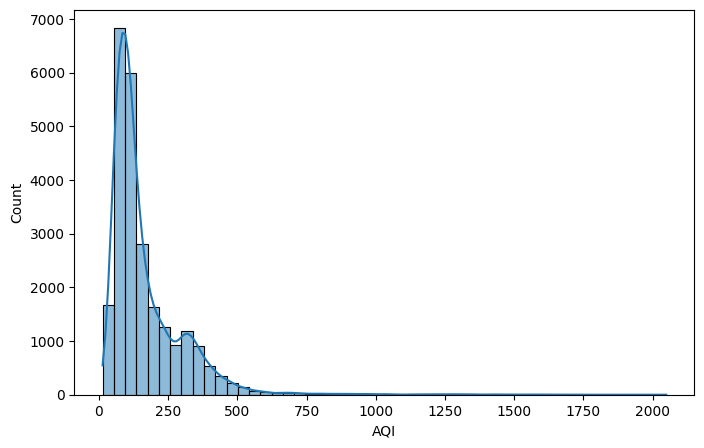

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['AQI'], bins=50, kde=True)
plt.show()

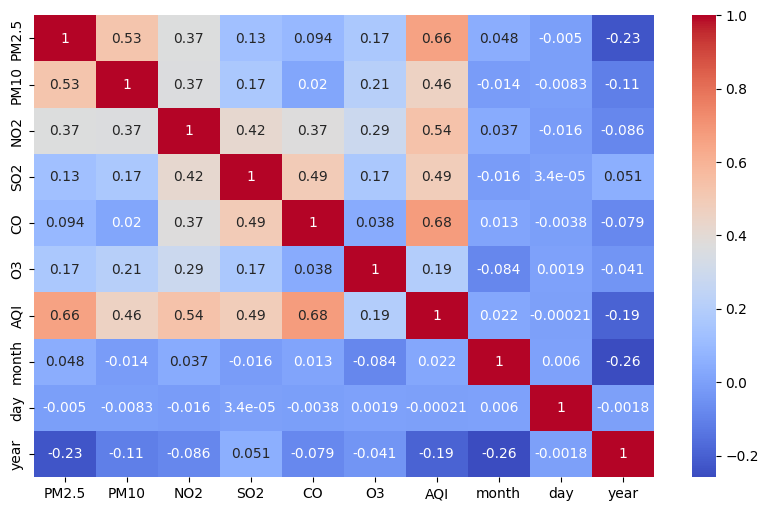

In [22]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.show()

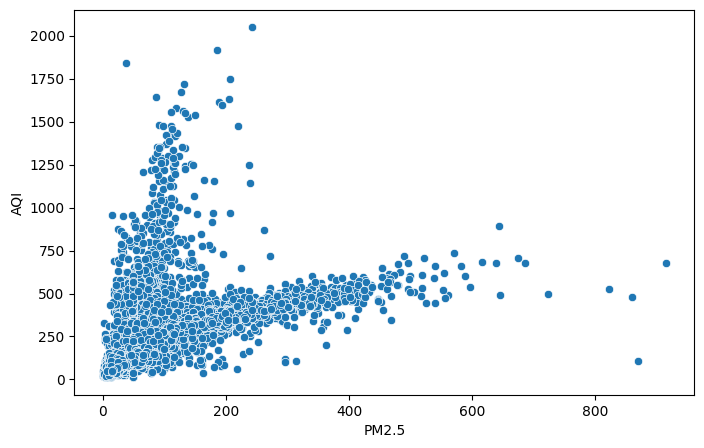

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='PM2.5', y='AQI', data=df)
plt.show()

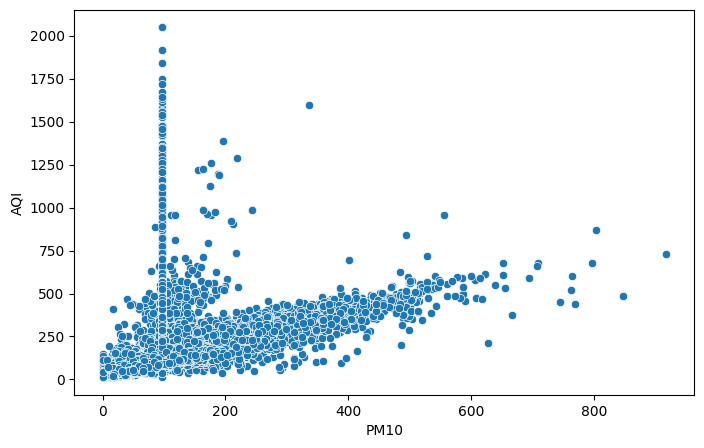

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='PM10', y='AQI', data=df)
plt.show()

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['City'] = le.fit_transform(df['City'])

In [28]:
X = df[['City','PM2.5','PM10','NO2','SO2','CO','O3','month','day','year']]

y = df['AQI']

In [29]:
df.head()

,City,Date,PM2.5,PM10,NO2,SO2,CO,O3,AQI,month,day,year
28,0,2015-01-29,83.13,96.18,28.71,49.52,6.93,59.76,209.0,1,3,2015
29,0,2015-01-30,79.84,96.18,28.68,48.49,13.85,97.07,328.0,1,4,2015
30,0,2015-01-31,94.52,96.18,32.66,67.39,24.39,111.33,514.0,1,5,2015
31,0,2015-02-01,135.99,96.18,42.08,75.23,43.48,102.70,782.0,2,6,2015
32,0,2015-02-02,178.33,96.18,35.31,55.04,54.56,107.38,914.0,2,0,2015


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
print(X_train.shape)
print(X_test.shape)

(19880, 10)
(4970, 10)


In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
model = LinearRegression()

In [35]:
model.fit(X_train, y_train)

LinearRegression()

In [36]:
y_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import r2_score, mean_squared_error

In [39]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 Score:", r2)
print("RMSE:", rmse)

R2 Score: 0.8074123737490504
RMSE: 59.3841401363297


In [40]:
from sklearn.ensemble import RandomForestRegressor

In [41]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [42]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [43]:
rf_pred = rf_model.predict(X_test)

In [44]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2_rf = r2_score(y_test, rf_pred)

mse_rf = mean_squared_error(y_test, rf_pred)
rmse_rf = np.sqrt(mse_rf)

print("Random Forest R2:", r2_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest R2: 0.909149286665625
Random Forest RMSE: 40.78687698765914


In [45]:
importance = rf_model.feature_importances_

features = X.columns

for f, imp in zip(features, importance):
    print(f, ":", imp)

City : 0.00672501194272428
PM2.5 : 0.49452587428625355
PM10 : 0.03793431898046707
NO2 : 0.014351390465808578
SO2 : 0.013519562788178063
CO : 0.3978914130985556
O3 : 0.016317386468841483
month : 0.005326945774963524
day : 0.00432994363894911
year : 0.00907815255525879


In [46]:
sample_data = [[
    3,      # City (encoded number)
    120,    # PM2.5
    150,    # PM10
    40,     # NO2
    10,     # SO2
    1.2,    # CO
    30,     # O3
    6,      # month
    2,      # day
    2020    # year
]]

In [49]:
prediction = rf_model.predict(sample_data)

print("Predicted AQI:", prediction[0])

Predicted AQI: 255.59


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [51]:
aqi = prediction[0]

if aqi <= 50:
    print("Air Quality: Good")
elif aqi <= 100:
    print("Air Quality: Satisfactory")
elif aqi <= 200:
    print("Air Quality: Moderate")
elif aqi <= 300:
    print("Air Quality: Poor")
elif aqi <= 400:
    print("Air Quality: Very Poor")
else:
    print("Air Quality: Severe")

Air Quality: Poor


In [57]:
sample_data = [[
    3,     # City (encoded value)
    10,    # PM2.5 (low)
    20,    # PM10 (low)
    5,     # NO2
    2,     # SO2
    0.3,   # CO
    15,    # O3
    6,     # month
    2,     # day
    2020   # year
]]

In [58]:
prediction = rf_model.predict(sample_data)

print("Predicted AQI:", prediction[0])

Predicted AQI: 33.5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [59]:
aqi = prediction[0]

if aqi <= 50:
    print("Air Quality: Good")
elif aqi <= 100:
    print("Air Quality: Satisfactory")
elif aqi <= 200:
    print("Air Quality: Moderate")
elif aqi <= 300:
    print("Air Quality: Poor")
elif aqi <= 400:
    print("Air Quality: Very Poor")
else:
    print("Air Quality: Severe")

Air Quality: Good
